# S&P 500 Return Correlation Network and Subsequent Market Outperformance Research question
Are degree centrality and clustering in a stock return correlation network associated with performance relative to the S&P 500 and do these relationships differ or hold across economic sectors?
This project is meant to treat each stock as a node. Two stocks are connected when their daily returns during the network creation period(1/1/24-12/31/24) have a sufficiently high positive correlation and each node has a categorical GICS sector attribute as well. Degree centrality and clustering coefficient are then calculated from the network and compared with the stock's subsequent return relative to SPY.
Study design
- Network creation period: 1/1/24 through 12/31/24
- Outcome period: 1/1/25 through 12/31/25
- Nodes: S&P 500 companies
- Edges: Pairwise return correlation greater than or equal to 0.60
- Categorical variable: GICS Sector
- Network measures: Degree centrality and clustering coefficient
- Outcome: Subsequent total return minus SPY total return
- Binary outcome: 1 if the stock outperformed SPY, otherwise 0


In [ ]:

#yfinance,pandas,numpy,networkx,matplotlib,scipy,statsmodels,scikit-learn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import yfinance as yf

from scipy import stats
import statsmodels.formula.api as smf

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


# Load S&P 500 data and sector classifications
The S&P 500 table provides the ticker symbols with the GICS sector classifications and Yahoo Finance was then used to obtain historical adjusted price data. This approach uses the current S&P 500 constituent list as opposed to a historically changing list or dollar weighted which can have some survivorship bias because companies that left the index list.

In [ ]:
import requests

SP500_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

#Adding a User Agent header to mimic a browser request
#this was a result of yfinance rejecting bulk request with read_html
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
response = requests.get(SP500_URL, headers=headers)

constituents = pd.read_html(response.text)[0][
    ["Symbol", "Security", "GICS Sector", "GICS Sub-Industry"]
].copy()

#Yahoo Finance uses "-" instead of "." in tickers such as BRK.B -> BRK-B
constituents["YahooSymbol"] = constituents["Symbol"].str.replace(".", "-", regex=False)

print(constituents.shape)
constituents.head()

(503, 5)


,Symbol,Security,GICS Sector,GICS Sub-Industry,YahooSymbol
0,MMM,3M,Industrials,Industrial Conglomerates,MMM
1,AOS,A. O. Smith,Industrials,Building Products,AOS
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,ABT
3,ABBV,AbbVie,Health Care,Biotechnology,ABBV
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,ACN


In [ ]:

#Download historical prices
#adjusted prices were used in post so that stock splits and distributions aren't creating fake seeming jumps in the return series
#time frame chosen to cover both the network formation period and the future outcome period

FORMATION_START = "2024-01-01"
FORMATION_END   = "2025-01-01"

OUTCOME_START   = "2025-01-01"
OUTCOME_END     = "2026-01-01"

CORR_THRESHOLD = 0.60
MIN_FORMATION_OBS = 200

tickers = constituents["YahooSymbol"].tolist()
download_tickers = tickers + ["SPY"]

raw = yf.download(
    download_tickers,
    start=FORMATION_START,
    end=OUTCOME_END,
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True
)

#yfinance returns a MultiIndex when many tickers are requested
if isinstance(raw.columns, pd.MultiIndex):
    prices = raw["Close"].copy()
else:
    prices = raw[["Close"]].rename(columns={"Close": download_tickers[0]})

prices = prices.sort_index()
print(prices.shape)
prices.tail()


ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['HONA', 'FDXF']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-01-01 -> 2026-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1704085200, endDate = 1767243600")')


(502, 504)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,AKAM,ALB,ALGN,ALL,ALLE,AMAT,...,WAB,WAT,WBD,WDAY,WDC,WEC,WELL,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-12-24,137.494431,273.066711,224.580185,136.779999,122.532806,96.400002,264.528992,352.980011,275.099640,56.612812,252.441833,298.209991,97.778595,112.722343,13.467072,108.919960,84.882545,239.347824,258.422180,88.820000,147.269669,157.839996,206.049988,159.020721,259.853882,...,219.001236,384.829987,29.230000,216.850006,179.369736,102.882027,185.698990,93.756538,218.565994,58.180153,110.903748,69.820183,187.498901,276.018463,331.286133,23.142776,124.117218,71.857536,116.875412,137.199127,66.050003,152.097137,89.509239,245.899994,123.553986
2025-12-26,137.563995,272.657837,224.668106,136.820007,122.562256,95.870003,265.616577,353.799988,274.386017,56.740189,253.165604,300.709991,97.749214,113.074265,13.573188,108.211029,84.843315,237.606308,259.125824,88.419998,148.757126,158.369995,204.817917,158.961395,260.969940,...,218.552780,386.059998,28.799999,220.699997,181.347626,102.833282,185.857285,93.717194,218.309280,58.238861,111.032936,69.750992,186.628067,273.663971,331.365387,23.123297,123.461990,72.177597,116.767570,137.268356,66.269997,151.032700,90.044922,246.270004,124.282570
2025-12-29,137.106750,273.016876,225.508240,136.619995,122.297188,96.389999,265.861511,353.160004,273.186737,57.043926,253.918701,301.230011,98.189926,113.172020,13.631070,108.270103,84.843315,238.902557,260.770874,88.239998,143.372482,157.839996,205.665588,159.515030,262.115845,...,216.410217,385.100006,28.790001,218.990005,179.489609,103.057472,187.618317,92.989166,219.484253,58.512829,111.817924,69.968445,185.193146,274.960938,330.919739,23.191477,121.387077,72.441483,118.159645,136.882660,65.919998,150.076660,89.806839,245.740005,124.036438
2025-12-30,136.798599,272.338715,224.433640,136.910004,123.485107,96.660004,264.548553,352.510010,272.383942,56.994934,253.840485,299.540009,98.660011,113.387085,13.988005,109.097198,84.499939,239.585312,259.472626,87.970001,140.823959,158.139999,206.099274,159.297531,259.046783,...,215.941833,383.989990,28.940001,216.929993,175.873444,103.408371,185.995789,92.782562,219.316406,58.865086,111.211784,69.978325,179.512848,276.227997,330.355225,23.366802,119.461098,72.509895,118.610596,136.071701,65.540001,149.987961,90.304161,246.740005,124.459801
2025-12-31,135.257858,271.122009,223.212524,135.720001,123.004059,95.919998,262.882904,349.989990,268.796021,56.328674,251.590912,296.010010,97.798180,112.722343,13.833654,108.575333,83.930916,238.318756,256.460022,87.250000,140.258728,156.149994,205.162903,157.409256,256.077362,...,212.713013,379.829987,28.820000,214.779999,172.087479,102.794296,183.631271,91.690544,216.936829,58.816162,110.705025,69.306213,176.732101,274.502045,326.323364,23.074596,119.461098,72.187370,117.973373,134.677261,65.089996,149.100922,89.438812,242.820007,123.878891


# Clean
Stocks must have enough observations during 2024 to support a meaningful return correlation estimate. Stocks without enough data were removed from the network and this can happen for newly listed firms, IPO'S, or companies that entered the S&P 500 after the formation period.

In [ ]:

formation_prices_all = prices.loc[
    (prices.index >= FORMATION_START) & (prices.index < FORMATION_END)
].copy()

available_counts = formation_prices_all.notna().sum()

eligible = [
    ticker for ticker in tickers
    if ticker in formation_prices_all.columns
    and available_counts.get(ticker, 0) >= MIN_FORMATION_OBS
]

print(f"Original constituent count: {len(tickers)}")
print(f"Eligible stocks: {len(eligible)}")
print(f"Removed for insufficient 2024 history: {len(tickers) - len(eligible)}")


Original constituent count: 503
Eligible stocks: 496
Removed for insufficient 2024 history: 7


#Daily returns, the correlation matrix, and the stock correlation network

Daily percentage returns are calculated for the 2024 formation period. The pairwise Pearson correlation matrix will define the edges of the network.
An undirected edge is created between two stocks when their daily return correlation is above 0.60 and the edge weight is the correlation.
This creates a simple undirected graph which a high degree stock is correlated and a high clustering stock has neighbors that are also correlated with one another.

In [ ]:
formation_prices = formation_prices_all[eligible].copy()

formation_returns = formation_prices.pct_change(fill_method=None)

# Pairwise correlations; require a reasonably large overlap in observations.
corr_matrix = formation_returns.corr(min_periods=MIN_FORMATION_OBS)

corr_matrix.iloc[:5, :5]

Ticker,MMM,AOS,ABT,ABBV,ACN
Ticker,,,,,
MMM,1.000000,0.279235,0.042417,0.123490,0.103162
AOS,0.279235,1.000000,0.113348,0.156557,0.187858
ABT,0.042417,0.113348,1.000000,0.296592,0.170712
ABBV,0.123490,0.156557,0.296592,1.000000,0.020888
ACN,0.103162,0.187858,0.170712,0.020888,1.000000


In [ ]:


G = nx.Graph()

meta = constituents.set_index("YahooSymbol")

for ticker in eligible:
    G.add_node(
        ticker,
        company=meta.loc[ticker, "Security"],
        sector=meta.loc[ticker, "GICS Sector"],
        subindustry=meta.loc[ticker, "GICS Sub-Industry"]
    )

for i, ticker_i in enumerate(eligible):
    for j in range(i + 1, len(eligible)):
        ticker_j = eligible[j]
        rho = corr_matrix.loc[ticker_i, ticker_j]

        if pd.notna(rho) and rho >= CORR_THRESHOLD:
            G.add_edge(ticker_i, ticker_j, weight=float(rho))

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.4f}")
print(f"Connected components: {nx.number_connected_components(G)}")


Nodes: 496
Edges: 936
Density: 0.0076
Connected components: 264


# Degree centrality and clustering coefficient
NetworkX degree centrality is the fraction of all other nodes to which a node is connected. The clustering coefficient measures the proportion of possible connections among a node's neighbors that actually exist. A value close to 1 indicates that the node belongs to a tightly interconnected group in its local area.

In [ ]:

#degree centrality
degree_centrality = nx.degree_centrality(G)
clustering = nx.clustering(G)

metrics = pd.DataFrame({
    "Ticker": list(G.nodes()),
    "Degree_Centrality": [degree_centrality[n] for n in G.nodes()],
    "Clustering": [clustering[n] for n in G.nodes()],
    "Degree": [G.degree(n) for n in G.nodes()]
})

metrics = metrics.merge(
    constituents[["YahooSymbol", "Symbol", "Security", "GICS Sector", "GICS Sub-Industry"]],
    left_on="Ticker",
    right_on="YahooSymbol",
    how="left"
).drop(columns="YahooSymbol")

metrics = metrics.rename(columns={
    "Security": "Company",
    "GICS Sector": "Sector",
    "GICS Sub-Industry": "SubIndustry"
})

metrics.sort_values("Degree_Centrality", ascending=False).head(15)


,Ticker,Degree_Centrality,Clustering,Degree,Symbol,Company,Sector,SubIndustry
221,GS,0.054545,0.538462,27,GS,Goldman Sachs,Financials,Investment Banking & Brokerage
373,PRU,0.052525,0.627692,26,PRU,Prudential Financial,Financials,Life & Health Insurance
332,NI,0.050505,0.673333,25,NI,NiSource,Utilities,Multi-Utilities
178,EVRG,0.050505,0.676667,25,EVRG,Evergy,Utilities,Electric Utilities
195,FITB,0.048485,0.699275,24,FITB,Fifth Third Bancorp,Financials,Regional Banks
164,EIX,0.048485,0.710145,24,EIX,Edison International,Utilities,Electric Utilities
368,PPL,0.048485,0.731884,24,PPL,PPL Corporation,Utilities,Electric Utilities
57,BAC,0.048485,0.717391,24,BAC,Bank of America,Financials,Diversified Banks
17,LNT,0.048485,0.717391,24,LNT,Alliant Energy,Utilities,Electric Utilities
157,DTE,0.046465,0.739130,23,DTE,DTE Energy,Utilities,Multi-Utilities


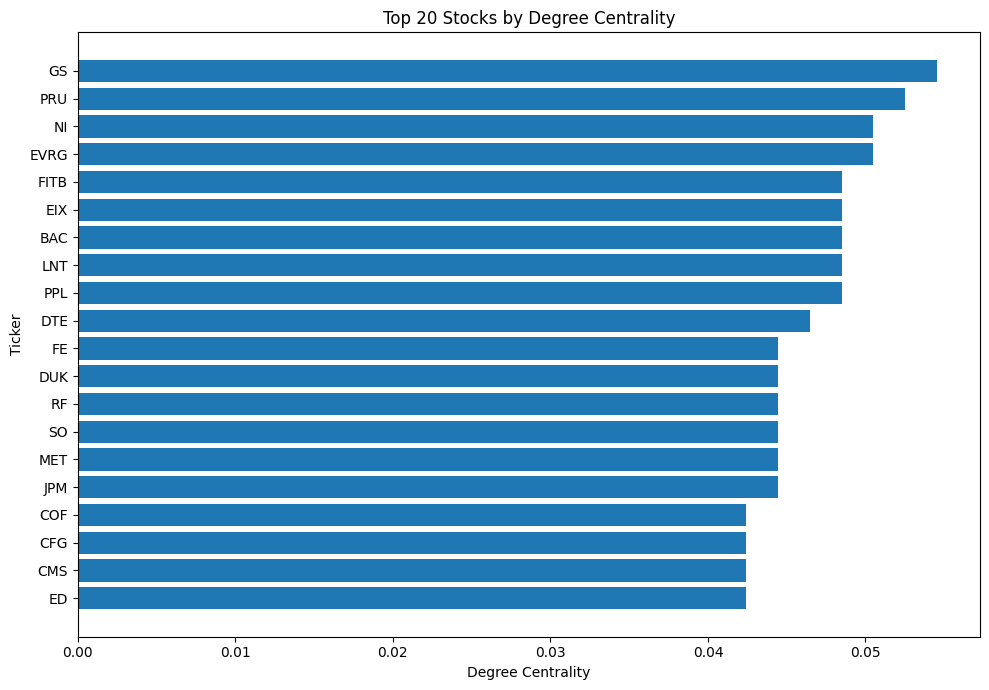

In [ ]:
#Highest centrality stocks

top_n = 20
top_degree = metrics.nlargest(top_n, "Degree_Centrality").sort_values("Degree_Centrality")

plt.figure(figsize=(10, 7))
plt.barh(top_degree["Ticker"], top_degree["Degree_Centrality"])
plt.xlabel("Degree Centrality")
plt.ylabel("Ticker")
plt.title(f"Top {top_n} Stocks by Degree Centrality")
plt.tight_layout()
plt.show()


In [ ]:

#Compare network position across sectors
#This directly addresses the assignment requirement to compare centrality across a categorical node attribute.

sector_summary = (
    metrics.groupby("Sector")
    .agg(
        Stocks=("Ticker", "count"),
        Mean_Degree_Centrality=("Degree_Centrality", "mean"),
        Median_Degree_Centrality=("Degree_Centrality", "median"),
        Mean_Clustering=("Clustering", "mean"),
        Median_Clustering=("Clustering", "median")
    )
    .sort_values("Mean_Degree_Centrality", ascending=False)
)

sector_summary


,Stocks,Mean_Degree_Centrality,Median_Degree_Centrality,Mean_Clustering,Median_Clustering
Sector,,,,,
Utilities,31,0.030564,0.036364,0.820901,0.929825
Financials,76,0.015444,0.006061,0.445894,0.519231
Real Estate,30,0.012593,0.012121,0.496805,0.554545
Energy,21,0.010967,0.006061,0.824339,0.972222
Information Technology,72,0.006594,0.002020,0.204655,0.000000
Industrials,80,0.004545,0.002020,0.170774,0.000000
Consumer Discretionary,47,0.002321,0.000000,0.167477,0.000000
Materials,25,0.001293,0.000000,0.086667,0.000000
Health Care,59,0.000753,0.000000,0.039548,0.000000


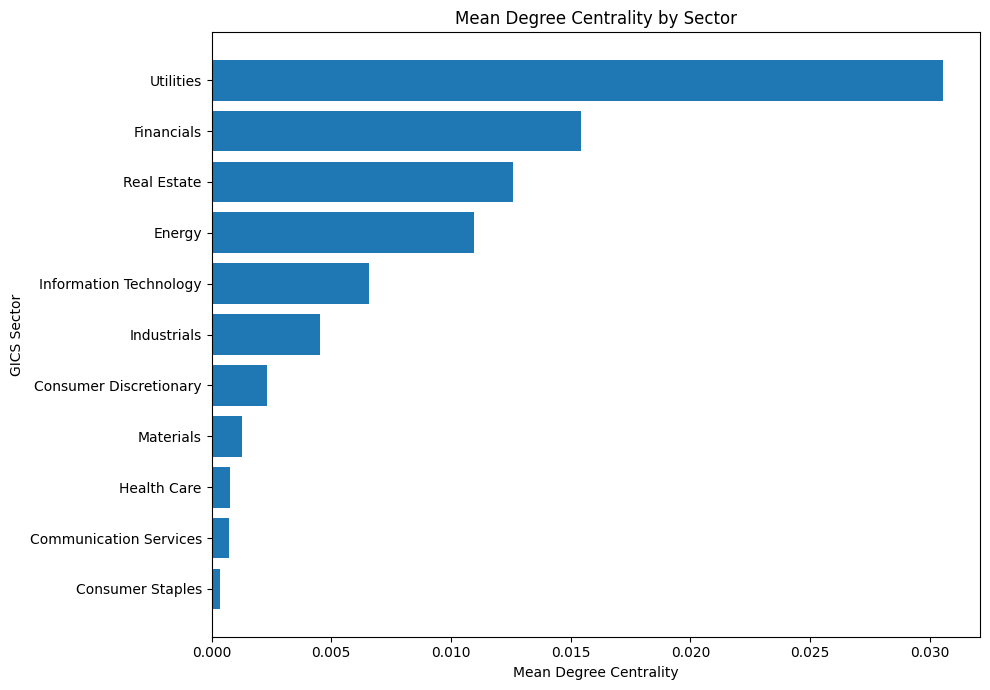

In [ ]:

#Avg centrality by sector
sector_plot = (
    sector_summary["Mean_Degree_Centrality"]
    .sort_values()
)

plt.figure(figsize=(10, 7))
plt.barh(sector_plot.index, sector_plot.values)
plt.xlabel("Mean Degree Centrality")
plt.ylabel("GICS Sector")
plt.title("Mean Degree Centrality by Sector")
plt.tight_layout()
plt.show()


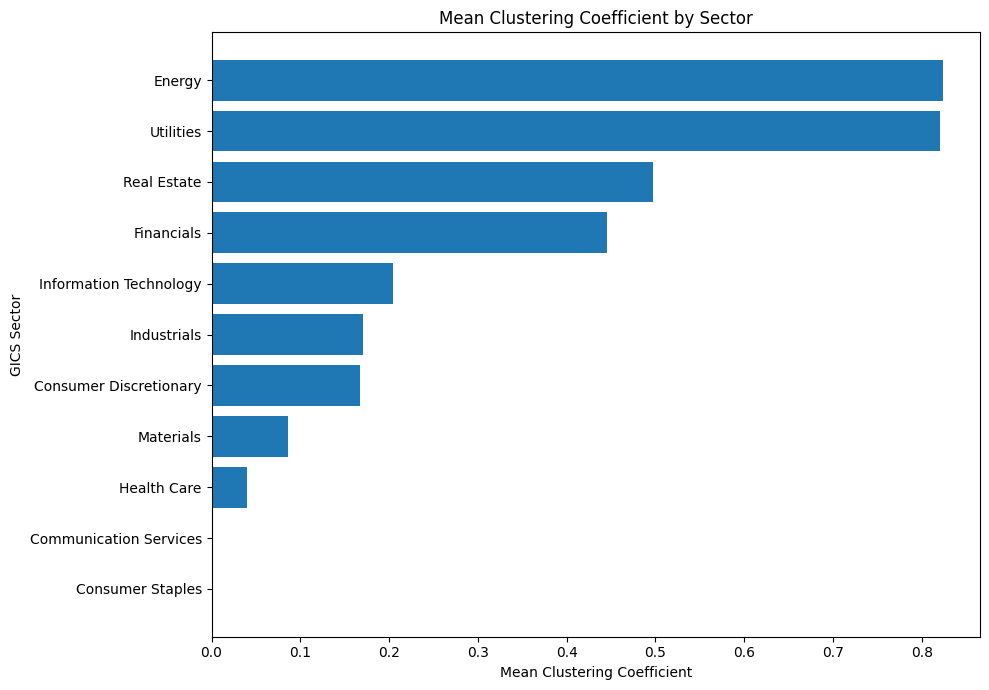

In [ ]:

#clustering coefficient by sector
sector_clustering = (
    sector_summary["Mean_Clustering"]
    .sort_values()
)

plt.figure(figsize=(10, 7))
plt.barh(sector_clustering.index, sector_clustering.values)
plt.xlabel("Mean Clustering Coefficient")
plt.ylabel("GICS Sector")
plt.title("Mean Clustering Coefficient by Sector")
plt.tight_layout()
plt.show()


In [ ]:
#Because centrality measures may not be normally distributed I did a Kruskal-Wallis test
#this started as a way to apply an ANOVA test that had to be augmented
#This will help tell if we have sector differences
degree_groups = [
    group["Degree_Centrality"].values
    for _, group in metrics.groupby("Sector")
    if len(group) >= 2
]

clustering_groups = [
    group["Clustering"].values
    for _, group in metrics.groupby("Sector")
    if len(group) >= 2
]

kw_degree = stats.kruskal(*degree_groups)
kw_cluster = stats.kruskal(*clustering_groups)

print("Kruskal-Wallis: Degree centrality across sectors")
print(f"H = {kw_degree.statistic:.4f}, p = {kw_degree.pvalue:.6g}")

print("\nKruskal-Wallis: Clustering across sectors")
print(f"H = {kw_cluster.statistic:.4f}, p = {kw_cluster.pvalue:.6g}")


Kruskal-Wallis: Degree centrality across sectors
H = 183.0721, p = 5.39196e-34

Kruskal-Wallis: Clustering across sectors
H = 185.4379, p = 1.73807e-34


# Krusal Wallis Results

ANOVA compares group means under assumptions such as approximate normality and similar variance. Kruskal Wallis is better when those assumptions are questionable because it works with the ranking of the observations rather than relying directly on the raw values. Since our H=183.07 and p=
5.39x10^-34 which is extremely small, we reject the null hypothesis and we must conclude there is strong evidence that degree centrality is different across economic sectors. This test doesn't tell us how these sectors differ but it does tell us they behave differently which leaves room for further exploration. We also see that our clustering coefficients differ between sectors which supports this theory.


# Calculate subsequent 2025 performance relative to SPY
Excess Return = Stock Return-SPY Return
A stock is then classified as either outperforming or underperforming SPY. The numerical value is 1 if the stock return is greater than the SPY return, and 0 if the stock return is less than or equal to the SPY return. Since prices are adjusted the return reflects the adjustments provided by the price data source.

In [ ]:

outcome_prices = prices.loc[
    (prices.index >= OUTCOME_START) & (prices.index < OUTCOME_END)
].copy()

def period_return(series):
    s = series.dropna()
    if len(s) < 2:
        return np.nan
    return (s.iloc[-1] / s.iloc[0]) - 1

stock_returns_2025 = {
    ticker: period_return(outcome_prices[ticker])
    for ticker in eligible
    if ticker in outcome_prices.columns
}

spy_return_2025 = period_return(outcome_prices["SPY"])

outcomes = pd.DataFrame({
    "Ticker": list(stock_returns_2025.keys()),
    "Future_Return": list(stock_returns_2025.values())
})

outcomes["SPY_Return"] = spy_return_2025
outcomes["Excess_Return"] = outcomes["Future_Return"] - outcomes["SPY_Return"]
outcomes["Outperform"] = (outcomes["Excess_Return"] > 0).astype(int)

analysis_df = metrics.merge(outcomes, on="Ticker", how="inner").dropna(
    subset=["Future_Return", "Excess_Return"]
)

print(f"SPY 2025 return: {spy_return_2025:.2%}")
print(f"Stocks with valid outcome data: {len(analysis_df)}")
print(f"Share outperforming SPY: {analysis_df['Outperform'].mean():.2%}")

analysis_df.head()


SPY 2025 return: 18.01%
Stocks with valid outcome data: 496
Share outperforming SPY: 33.87%


,Ticker,Degree_Centrality,Clustering,Degree,Symbol,Company,Sector,SubIndustry,Future_Return,SPY_Return,Excess_Return,Outperform
0,MMM,0.00000,0.0,0,MMM,3M,Industrials,Industrial Conglomerates,0.257692,0.18009,0.077602,1
1,AOS,0.00202,0.0,1,AOS,A. O. Smith,Industrials,Building Products,0.013762,0.18009,-0.166329,0
2,ABT,0.00000,0.0,0,ABT,Abbott Laboratories,Health Care,Health Care Equipment,0.125388,0.18009,-0.054702,0
3,ABBV,0.00000,0.0,0,ABBV,AbbVie,Health Care,Biotechnology,0.317874,0.18009,0.137784,1
4,ACN,0.00202,0.0,1,ACN,Accenture,Information Technology,IT Consulting & Other Services,-0.219854,0.18009,-0.399944,0


In [ ]:

#Compare network measures for outperformers and underperformers
performance_groups = (
    analysis_df.assign(
        Performance_Group=np.where(
            analysis_df["Outperform"].eq(1),
            "Outperformed SPY",
            "Underperformed SPY"
        )
    )
    .groupby("Performance_Group")
    .agg(
        Stocks=("Ticker", "count"),
        Mean_Degree_Centrality=("Degree_Centrality", "mean"),
        Median_Degree_Centrality=("Degree_Centrality", "median"),
        Mean_Clustering=("Clustering", "mean"),
        Median_Clustering=("Clustering", "median"),
        Mean_Excess_Return=("Excess_Return", "mean")
    )
)

performance_groups


,Stocks,Mean_Degree_Centrality,Median_Degree_Centrality,Mean_Clustering,Median_Clustering,Mean_Excess_Return
Performance_Group,,,,,,
Outperformed SPY,168,0.008670,0.00202,0.270687,0.0,0.37209
Underperformed SPY,328,0.007089,0.00202,0.264769,0.0,-0.20830


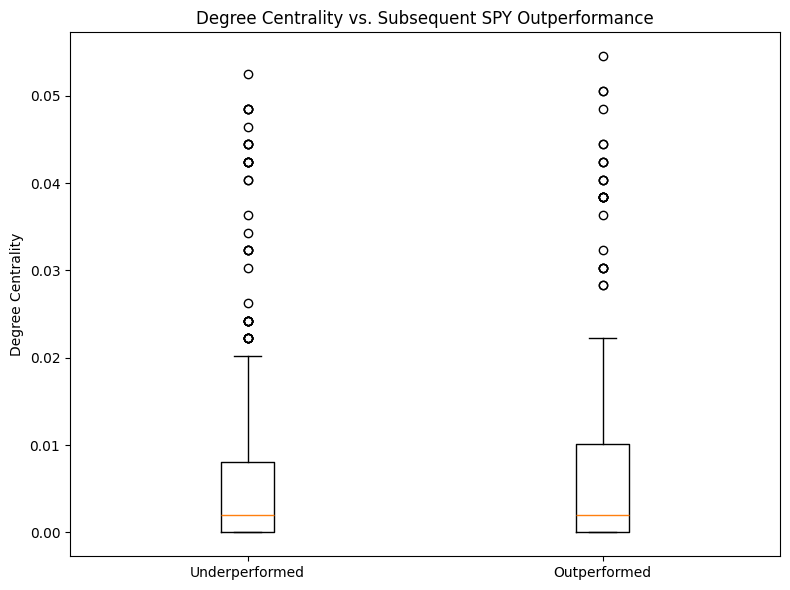

In [ ]:

plot_df = analysis_df.copy()
plot_df["Performance_Group"] = np.where(
    plot_df["Outperform"].eq(1),
    "Outperformed",
    "Underperformed"
)

degree_box_data = [
    plot_df.loc[plot_df["Performance_Group"] == "Underperformed", "Degree_Centrality"],
    plot_df.loc[plot_df["Performance_Group"] == "Outperformed", "Degree_Centrality"]
]

plt.figure(figsize=(8, 6))
plt.boxplot(degree_box_data, tick_labels=["Underperformed", "Outperformed"])
plt.ylabel("Degree Centrality")
plt.title("Degree Centrality vs. Subsequent SPY Outperformance")
plt.tight_layout()
plt.show()


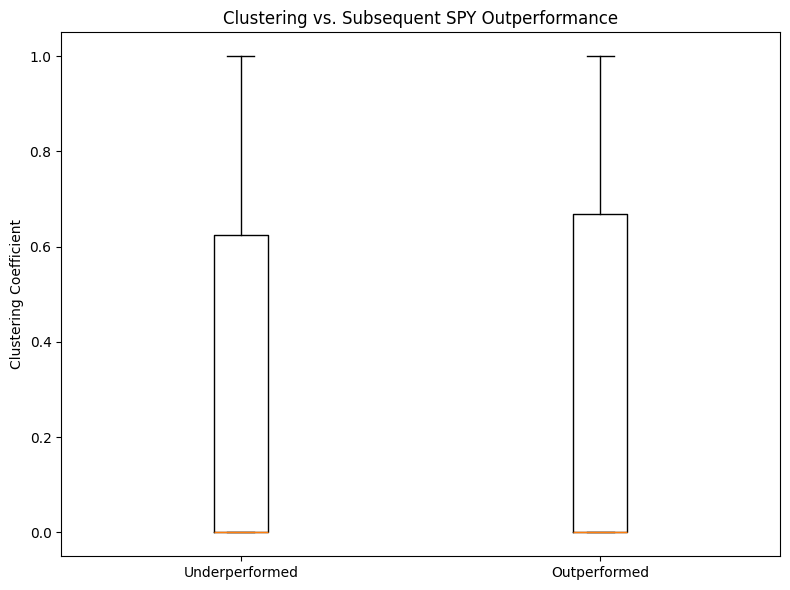

In [ ]:

cluster_box_data = [
    plot_df.loc[plot_df["Performance_Group"] == "Underperformed", "Clustering"],
    plot_df.loc[plot_df["Performance_Group"] == "Outperformed", "Clustering"]
]

plt.figure(figsize=(8, 6))
plt.boxplot(cluster_box_data, tick_labels=["Underperformed", "Outperformed"])
plt.ylabel("Clustering Coefficient")
plt.title("Clustering vs. Subsequent SPY Outperformance")
plt.tight_layout()
plt.show()


We have different quartiles in the two categories but ultimately it doesn't seem that performance is majorly biased in one direction from our boxplots.

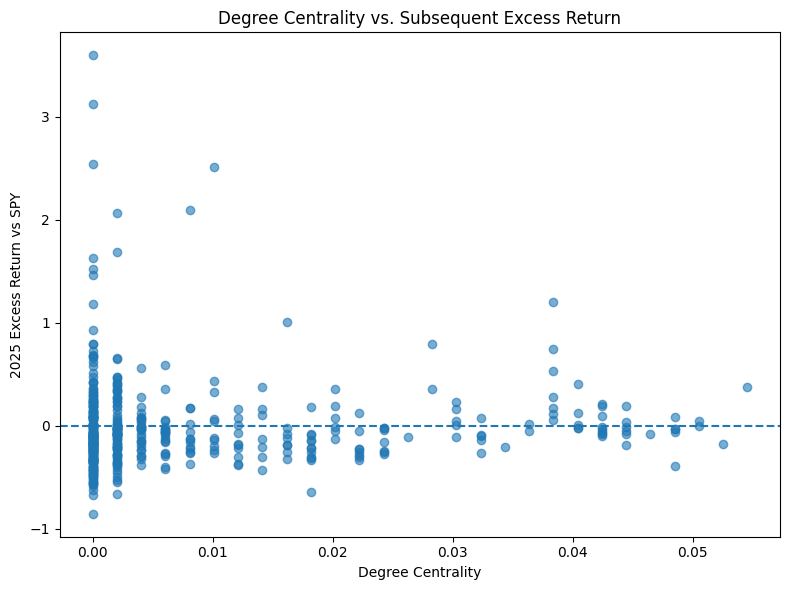

Spearman rho: 0.1002
p-value: 0.0256543


In [ ]:

plt.figure(figsize=(8, 6))
plt.scatter(analysis_df["Degree_Centrality"], analysis_df["Excess_Return"], alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Degree Centrality")
plt.ylabel("2025 Excess Return vs SPY")
plt.title("Degree Centrality vs. Subsequent Excess Return")
plt.tight_layout()
plt.show()

rho_degree, p_degree = stats.spearmanr(
    analysis_df["Degree_Centrality"],
    analysis_df["Excess_Return"],
    nan_policy="omit"
)

print(f"Spearman rho: {rho_degree:.4f}")
print(f"p-value: {p_degree:.6g}")


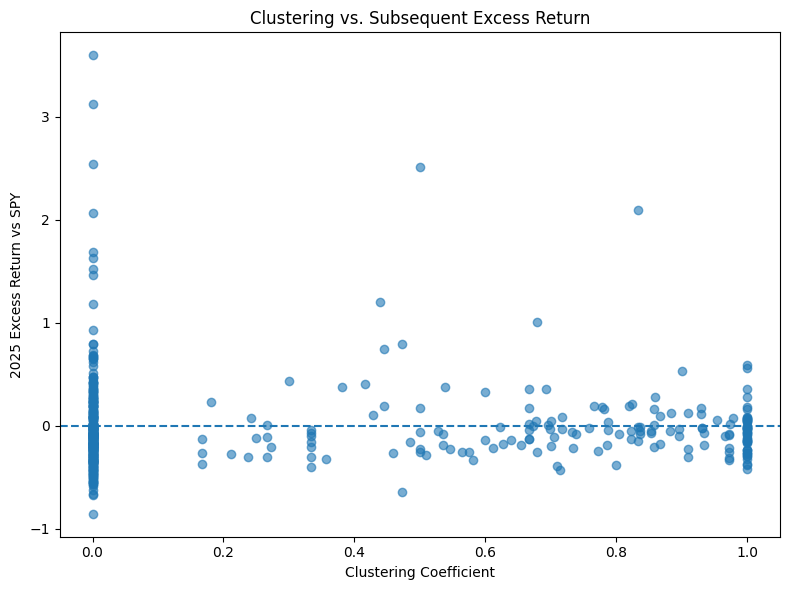

Spearman rho: 0.0661
p-value: 0.141492


In [ ]:

plt.figure(figsize=(8, 6))
plt.scatter(analysis_df["Clustering"], analysis_df["Excess_Return"], alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Clustering Coefficient")
plt.ylabel("2025 Excess Return vs SPY")
plt.title("Clustering vs. Subsequent Excess Return")
plt.tight_layout()
plt.show()

rho_cluster, p_cluster = stats.spearmanr(
    analysis_df["Clustering"],
    analysis_df["Excess_Return"],
    nan_policy="omit"
)

print(f"Spearman rho: {rho_cluster:.4f}")
print(f"p-value: {p_cluster:.6g}")


# Regression
A simple regression to see whether degree centrality and clustering are associated with returns while controlling for sector.
This is meant to be an association and prediction model to potentially explore further evidence.

In [ ]:

ols_model = smf.ols(
    "Excess_Return ~ Degree_Centrality + Clustering + C(Sector)",
    data=analysis_df
).fit(cov_type="HC3")

print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:          Excess_Return   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     3.425
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           7.61e-05
Time:                        01:52:49   Log-Likelihood:                -276.94
No. Observations:                 496   AIC:                             579.9
Df Residuals:                     483   BIC:                             634.6
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

The OLS model was statistically significant overall F = 3.43, p < 0.001, but it explained only a small portion of the variation in returns with an R^2 of 0.066. Degree centrality had a positive value but it wasn't statistically significant at p = 0.170, and clustering also wasn't significant p = 0.574. This suggests after accounting for sector there wasn't strong evidence that degree centrality or clustering predicted 2025 excess returns relative to SPY. Interestgly though, with such a small variance we must wonder if this is useful in a larger combined model under certain conditions.

#Can network measures help distinguish outperformers
This model uses degree centrality, clustering, and sector to classify whether each stock subsequently beats SPY.
Five fold stratified cross validation is used so that model performance is evaluated on observations not used to fit each fold.The data was divided into five subsets for split while preserving the proportion of outperforming and underperforming stocks. The model was trained on four subsets and tested on the remaining subset, allowing performance to be tested on observations not just used during model fitting. This was done for results accuracy and would be interesting as well to see in different sample sizes for different interest rate environments.

In [ ]:

X = analysis_df[["Degree_Centrality", "Clustering", "Sector"]]
y = analysis_df["Outperform"]

numeric_features = ["Degree_Centrality", "Clustering"]
categorical_features = ["Sector"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

logit_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=2000))
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = cross_val_score(
    logit_pipeline,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

accuracy_scores = cross_val_score(
    logit_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print(f"Mean CV ROC AUC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")
print(f"Mean CV Accuracy: {accuracy_scores.mean():.3f} ± {accuracy_scores.std():.3f}")
print(f"Naive majority-class accuracy: {max(y.mean(), 1-y.mean()):.3f}")


Mean CV ROC AUC: 0.581 ± 0.036
Mean CV Accuracy: 0.657 ± 0.008
Naive majority-class accuracy: 0.661


#Threshold sensitivity analysis
A correlation cutoff is a model decision. Results should not depend entirely on an arbitrary choice of 0.60. The code rebuilds the graph with several thresholds and reports size and network statistics.

In [ ]:

def graph_from_correlation(corr, nodes, threshold):
    graph = nx.Graph()
    graph.add_nodes_from(nodes)

    for i, a in enumerate(nodes):
        for j in range(i + 1, len(nodes)):
            b = nodes[j]
            rho = corr.loc[a, b]
            if pd.notna(rho) and rho >= threshold:
                graph.add_edge(a, b, weight=float(rho))
    return graph

sensitivity_rows = []

for threshold in [0.50, 0.55, 0.60, 0.65, 0.70]:
    g_temp = graph_from_correlation(corr_matrix, eligible, threshold)
    dc_temp = nx.degree_centrality(g_temp)
    cc_temp = nx.clustering(g_temp)

    sensitivity_rows.append({
        "Correlation_Threshold": threshold,
        "Edges": g_temp.number_of_edges(),
        "Density": nx.density(g_temp),
        "Mean_Degree_Centrality": np.mean(list(dc_temp.values())),
        "Mean_Clustering": np.mean(list(cc_temp.values()))
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df


,Correlation_Threshold,Edges,Density,Mean_Degree_Centrality,Mean_Clustering
0,0.50,2537,0.020666,0.020666,0.369150
1,0.55,1532,0.012480,0.012480,0.311839
2,0.60,936,0.007625,0.007625,0.266774
3,0.65,576,0.004692,0.004692,0.210683
4,0.70,354,0.002884,0.002884,0.143201


#Top nodes
A complete S&P 500 network could be unreadable so I created a graphcontaining the 40 highest-degree nodes.

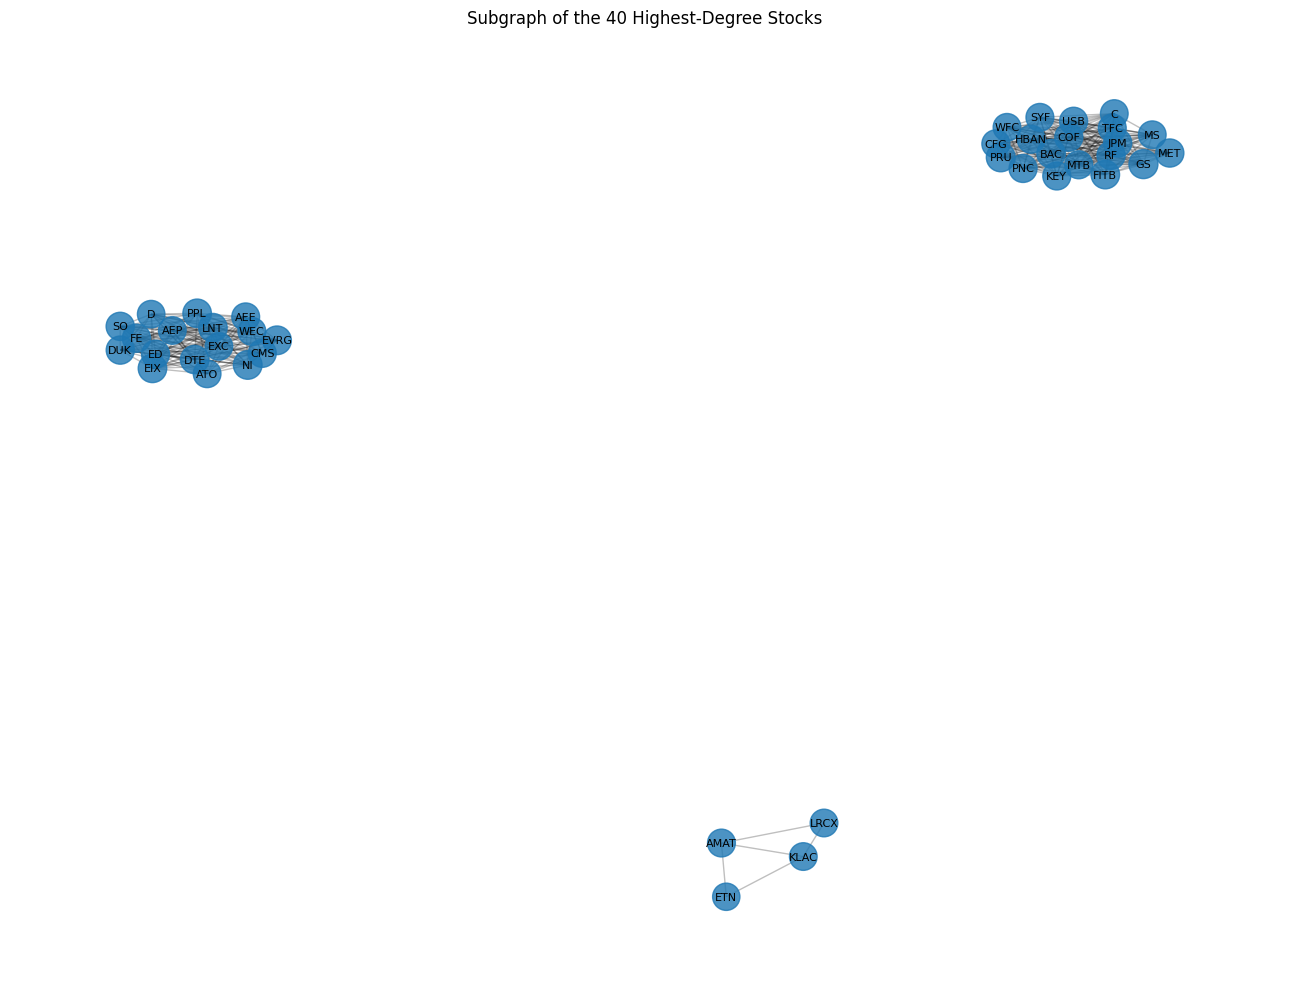

In [ ]:

top_nodes = (
    metrics.nlargest(40, "Degree_Centrality")["Ticker"]
    .tolist()
)

H = G.subgraph(top_nodes).copy()

plt.figure(figsize=(13, 10))
pos = nx.spring_layout(H, seed=42, weight="weight")

node_sizes = [
    300 + 2500 * degree_centrality[n]
    for n in H.nodes()
]

nx.draw_networkx_nodes(H, pos, node_size=node_sizes, alpha=0.8)
nx.draw_networkx_edges(H, pos, alpha=0.25)
nx.draw_networkx_labels(H, pos, font_size=8)

plt.title("Subgraph of the 40 Highest-Degree Stocks")
plt.axis("off")
plt.tight_layout()
plt.show()


# Conclusion
The return correlation network contained 496 stocks with valid subsequent performance data. Using a correlation threshold of 0.60 the network contained 936 edges and had a density of about 0.0076 telling us that it was only a small proportion of all possible stock pairs were strongly correlated enough to form an edge. Network structure varied substantially across sectors. Utilities exhibited the highest average degree centrality 0.0306, then Financials 0.0154, and Real Estate 0.0126. Utilities and Energy also displayed high average clustering coefficients, suggesting that stocks within these sectors tended to form relatively dense local groupings. During 2025 SPY returned about 18.0%, while 33.9% of the analyzed S&P 500 stocks outperformed SPY. Degree centrality distributions were visually similar between stocks that outperformed and underperformed the benchmark. Scatterplots of degree centrality and clustering against excess returns showed no clear directional relationship.
An OLS regression using excess return relative to SPY as the dependent variable and degree centrality, clustering, and sector as predictors produced an R^2 of 0.066 and an adjusted R^2 of 0.043. Degree centrality had a positive estimated coefficient of 2.19, but the relationship just wasn't statistically significant p=0.170. The clustering coefficient was also not statistically significant p=0.574. That's why within this sample there wasn't strong evidence that either degree centrality or local clustering independently predicted subsequent excess returns after accounting for sector.
